# SW-7: train a YOLO11n pothole detector for the Raspberry Pi

Trains YOLO11n on a public pothole dataset from Roboflow Universe, records the accuracy and settings for the report, and converts the result to NCNN for `CameraDetection/yolo_bench.py` on the Pi.

Before running:
1. Runtime > Change runtime type > **T4 GPU**.
2. Secrets (key icon on the left): add `ROBOFLOW_API_KEY` with your Roboflow key, and allow this notebook to use it. Do not type the key into a cell.
3. On the dataset's Universe page: Download Dataset > format **YOLOv11** > "show download code". Copy the workspace, project and version into cell 3.

No camera frames from the vehicle are used: only the public dataset.

In [1]:
# 1. GPU check
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [2]:
# 2. Packages, and Google Drive so training survives a disconnect
!pip -q install ultralytics roboflow
from google.colab import drive
drive.mount('/content/drive')
import os
RUN_DIR = '/content/drive/MyDrive/SW7_training'
os.makedirs(RUN_DIR, exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.6/333.6 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.3 MB/s eta 0:00:00
Mounted at /content/drive


In [3]:
# 2b. South African pothole dataset straight from Kaggle (Nienaber, Kroon and Booysen, Stellenbosch University,
#     SATC 2015; CC0 1.0). Needs a Colab secret: KAGGLE_API_TOKEN (kaggle.com > Settings > API Tokens >
#     Generate New Token), or the legacy pair KAGGLE_USERNAME and KAGGLE_KEY from kaggle.json.
#     This cell only downloads and shows the layout, so the label format can be checked before it is
#     converted or uploaded to Roboflow.
!pip -q install -U "kagglehub>=0.4.1"
import os, glob
from google.colab import userdata
def secret(name):
    try: return userdata.get(name)
    except Exception: return None
if secret('KAGGLE_API_TOKEN'):
    os.environ['KAGGLE_API_TOKEN'] = secret('KAGGLE_API_TOKEN')
elif secret('KAGGLE_USERNAME') and secret('KAGGLE_KEY'):
    os.environ['KAGGLE_USERNAME'] = secret('KAGGLE_USERNAME'); os.environ['KAGGLE_KEY'] = secret('KAGGLE_KEY')
else:
    print('No Kaggle secret found; trying without (works for some public datasets).')
import kagglehub
SA_DIR = kagglehub.dataset_download('sovitrath/road-pothole-images-for-pothole-detection')
print('downloaded to', SA_DIR)
for root, dirs, files in os.walk(SA_DIR):
    depth = root[len(SA_DIR):].count(os.sep)
    if depth > 3: continue
    exts = sorted({os.path.splitext(f)[1].lower() for f in files})
    print('  ' * depth + os.path.basename(root) + '/', len(files), 'files', exts)
labels = [f for f in glob.glob(SA_DIR + '/**/*', recursive=True) if f.lower().endswith(('.txt', '.xml', '.json', '.csv'))]
print(len(labels), 'label-like files; first one:', labels[:1])
if labels: print(open(labels[0]).read()[:600])

No Kaggle secret found; trying without (works for some public datasets).


100%|██████████| 8.82G/8.82G [01:41<00:00, 93.6MB/s]

Extracting files...


downloaded to /root/.cache/kagglehub/datasets/sovitrath/road-pothole-images-for-pothole-detection/versions/2
2/ 2 files ['.csv', '.pdf']
  Dataset 1 (Simplex)/ 0 files []
    Dataset 1 (Simplex)/ 2 files ['.txt']
      Test data/ 628 files ['.jpg']
      Train data/ 0 files []
3 label-like files; first one: ['/root/.cache/kagglehub/datasets/sovitrath/road-pothole-images-for-pothole-detection/versions/2/train_df.csv']
image_id,num_potholes,x,y,w,h
G0010033,6,1990,1406,66,14
G0010033,6,1464,1442,92,16
G0010033,6,1108,1450,54,16
G0010033,6,558,1434,102,16
G0010033,6,338,1450,72,18
G0010033,6,262,1450,58,22
G0010034,5,1804,1424,90,16
G0010034,5,1192,1484,110,16
G0010034,5,782,1502,74,16
G0010034,5,566,1494,106,22
G0010034,5,210,1484,104,22
G0010035,4,1590,1452,106,24
G0010035,4,840,1544,132,28
G0010035,4,368,1584,96,22
G0010035,4,136,1576,138,30
G0010036,3,1322,1516,134,28
G0010036,3,362,1658,156,38
G0010036,3,1744,1522,58,16
G0010037,2,884,1638,190,52
G0010037,2,1428,1654,98,26
G0010109,2

In [10]:
# 2c. Inspect the South African dataset fully
import os, glob, csv
from PIL import Image
for root, dirs, files in os.walk(SA_DIR):
    d = root[len(SA_DIR):].count(os.sep)
    exts = sorted({os.path.splitext(f)[1].lower() for f in files})
    print('  ' * d + os.path.basename(root) + '/', len(files), 'files', exts)
for f in glob.glob(SA_DIR + '/**/*.csv', recursive=True) + glob.glob(SA_DIR + '/**/*.txt', recursive=True):
    rows = open(f).read().splitlines()
    print('\n==', f.replace(SA_DIR, ''), len(rows), 'lines'); print('\n'.join(rows[:4]))
imgs = glob.glob(SA_DIR + '/**/*.jpg', recursive=True) + glob.glob(SA_DIR + '/**/*.JPG', recursive=True)
print('\n', len(imgs), 'jpg images; first image size:', Image.open(imgs[0]).size if imgs else None)


2/ 2 files ['.csv', '.pdf']
  Dataset 1 (Simplex)/ 0 files []
    Dataset 1 (Simplex)/ 2 files ['.txt']
      Test data/ 628 files ['.jpg']
      Train data/ 0 files []
        Positive data/ 1119 files ['.jpg']
        Negative data/ 2658 files ['.jpg']

== /train_df.csv 4593 lines
image_id,num_potholes,x,y,w,h
G0010033,6,1990,1406,66,14
G0010033,6,1464,1442,92,16
G0010033,6,1108,1450,54,16

== /Dataset 1 (Simplex)/Dataset 1 (Simplex)/simpleTrainFullPhotosSortedFullAnnotations.txt 1661 lines
Train data\Positive data\G0010033.bmp 6 1990 1406 66 14 1464 1442 92 16 1108 1450 54 16 558 1434 102 16 338 1450 72 18 262 1450 58 22                                
Train data\Positive data\G0010034.bmp 5 1804 1424 90 16 1192 1484 110 16 782 1502 74 16 566 1494 106 22 210 1484 104 22                                    
Train data\Positive data\G0010035.bmp 4 1590 1452 106 24 840 1544 132 28 368 1584 96 22 136 1576 138 30                                        
Train data\Positive data\G0010036.bm

In [14]:
# 2d. Convert the South African labels to YOLO format (full frames) and measure pothole sizes
import os, glob, random, re, statistics as st, yaml
from PIL import Image
OUT = '/content/sa_yolo'
root = glob.glob(SA_DIR + '/**/Dataset 1 (Simplex)/Dataset 1 (Simplex)', recursive=True)[0]
imgs = {os.path.splitext(os.path.basename(p))[0]: p for p in glob.glob(root + '/**/*.[jJ][pP][gG]', recursive=True)}
# same 5 class names as the Roboflow set, so the two datasets can be merged later
names = ['Manhole', 'Open Manhole', 'Pothole', 'Speed Bump', 'Unmarked Bump']
if os.path.exists('/content/dataset/data.yaml'):
    names = yaml.safe_load(open('/content/dataset/data.yaml'))['names']
POT = next(i for i, n in enumerate(names) if 'pothole' in n.lower())
ann = {}                                   # image stem -> list of (x, y, w, h) in pixels
for txt in glob.glob(root + '/*.txt'):
    for line in open(txt).read().splitlines():
        m = re.match(r'^(.*?\.(?:bmp|jpg|jpeg|png))\s+(.*)$', line.strip().replace('\\', '/'), re.I)
        if not m: continue
        nums = m.group(2).split()
        stem, n = os.path.splitext(os.path.basename(m.group(1)))[0], int(nums[0])
        v = list(map(int, nums[1:1 + 4 * n]))
        ann[stem] = [tuple(v[i:i + 4]) for i in range(0, len(v), 4)]
    print(os.path.basename(txt), '->', sum(1 for _ in open(txt)), 'lines')
size = Image.open(next(iter(imgs.values()))).size
W, H = size
boxes = [b for bs in ann.values() for b in bs]
print('images found:', len(imgs), '| annotated images:', len(ann), '| boxes:', len(boxes), '| image size:', size)
q = lambda v: [round(x) for x in st.quantiles(v, n=10)[::4]]   # 10th, 50th, 90th percentile
print('box width px  p10/p50/p90:', q([b[2] for b in boxes]), '-> at 640 wide:', [round(x * 640 / W, 1) for x in q([b[2] for b in boxes])])
print('box height px p10/p50/p90:', q([b[3] for b in boxes]), '-> at 640 wide:', [round(x * 640 / W, 1) for x in q([b[3] for b in boxes])])
print('box centre y as fraction of height p10/p50/p90:', [round((b[1] + b[3] / 2) / H, 2) for b in sorted(boxes, key=lambda b: b[1])[len(boxes)//10::len(boxes)*4//10]][:3])
def split_of(p):
    return 'test' if '/Test data/' in p.replace('\\', '/') else 'train'
random.seed(0)
pos = [s for s, p in imgs.items() if split_of(p) == 'train' and ann.get(s)]
neg = [s for s, p in imgs.items() if split_of(p) == 'train' and not ann.get(s)]
neg = random.sample(neg, min(len(neg), len(pos)))   # one empty image per pothole image
train = pos + neg; random.shuffle(train)
nval = len(train) * 15 // 100
plan = {'val': train[:nval], 'train': train[nval:], 'test': [s for s, p in imgs.items() if split_of(p) == 'test']}
for sp, stems in plan.items():
    os.makedirs(f'{OUT}/{sp}/images', exist_ok=True); os.makedirs(f'{OUT}/{sp}/labels', exist_ok=True)
    for s in stems:
        dst = f'{OUT}/{sp}/images/{s}.jpg'
        if not os.path.exists(dst): os.symlink(imgs[s], dst)
        with open(f'{OUT}/{sp}/labels/{s}.txt', 'w') as f:
            for x, y, w, h in ann.get(s, []):
                f.write(f'{POT} {(x + w / 2) / W:.6f} {(y + h / 2) / H:.6f} {w / W:.6f} {h / H:.6f}\n')
    print(sp, len(stems), 'images,', sum(len(ann.get(s, [])) for s in stems), 'potholes')
SA_YAML = f'{OUT}/data.yaml'
yaml.safe_dump({'path': OUT, 'train': 'train/images', 'val': 'val/images', 'test': 'test/images', 'names': names}, open(SA_YAML, 'w'))
print('wrote', SA_YAML)


simpleTrainFullPhotosSortedFullAnnotations.txt -> 1661 lines
simpleTestFullSizeAllPotholesSortedFullAnnotation.txt -> 650 lines
images found: 4337 | annotated images: 1987 | boxes: 5029 | image size: (3680, 2760)
box width px  p10/p50/p90: [46, 100, 220] -> at 640 wide: [8.0, 17.4, 38.3]
box height px p10/p50/p90: [12, 26, 66] -> at 640 wide: [2.1, 4.5, 11.5]
box centre y as fraction of height p10/p50/p90: [0.48, 0.57, 0.62]
val 345 images, 463 potholes
train 1959 images, 2726 potholes
test 605 images, 1238 potholes
wrote /content/sa_yolo/data.yaml


In [15]:
# 2e. Run 1's model on the South African test images, at three input sizes (no training)
from ultralytics import YOLO
m = YOLO(f'{RUN_DIR}/yolo11n_pothole_640/weights/best.pt')
for sz in (640, 1280, 1920):
    r = m.val(data=SA_YAML, split='test', imgsz=sz, batch=8, plots=False, verbose=False,
              project=RUN_DIR, name=f'run1_on_SA_test_{sz}', exist_ok=True)
    print(f'imgsz {sz}: mAP50 {r.box.map50:.3f}  mAP50-95 {r.box.map:.3f}  P {r.box.mp:.3f}  R {r.box.mr:.3f}')


Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 103.7±24.2 MB/s, size: 2131.1 KB)
val: Scanning /content/sa_yolo/test/labels... 605 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 605/605 155.5it/s 3.9s
val: New cache created: /content/sa_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 76/76 1.4it/s 56.3s
                   all        605       1238   0.000334    0.00162   2.23e-06    4.1e-07
Speed: 1.2ms preprocess, 6.1ms inference, 0.0ms loss, 1.9ms postprocess per image
imgsz 640: mAP50 0.000  mAP50-95 0.000  P 0.000  R 0.002
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms

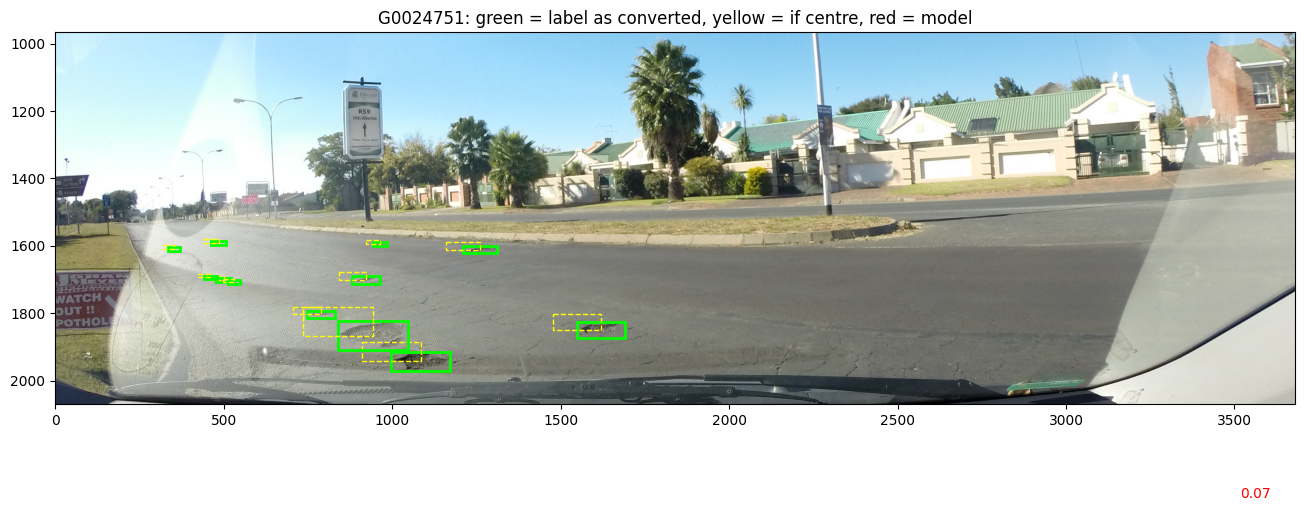

12 labelled potholes; 1 detections at conf 0.05


In [16]:
# 2f. Visual check: are the labels in the right place, and what does the model detect?
import matplotlib.pyplot as plt, matplotlib.patches as pa
from PIL import Image
test = sorted(plan['test'], key=lambda s: -len(ann.get(s, [])))[0]      # test image with the most potholes
im = Image.open(imgs[test]); W, H = im.size
fig, ax = plt.subplots(figsize=(16, 7)); ax.imshow(im)
for x, y, w, h in ann[test]:
    ax.add_patch(pa.Rectangle((x, y), w, h, fill=False, ec='lime', lw=2))                  # as converted: x, y = top-left
    ax.add_patch(pa.Rectangle((x - w/2, y - h/2), w, h, fill=False, ec='yellow', lw=1, ls='--'))  # if x, y were the centre
res = m.predict(imgs[test], imgsz=1280, conf=0.05, verbose=False)[0]
for (x1, y1, x2, y2), c in zip(res.boxes.xyxy.tolist(), res.boxes.conf.tolist()):
    ax.add_patch(pa.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec='red', lw=2)); ax.text(x1, y1-8, f'{c:.2f}', color='red')
ax.set_ylim(H * 0.75, H * 0.35); ax.set_title(f'{test}: green = label as converted, yellow = if centre, red = model'); plt.show()
print(len(ann[test]), 'labelled potholes;', len(res.boxes), 'detections at conf 0.05')


In [17]:
# 2g. South African band tiles: crop rows 42-70% of the height, cut into 3 overlapping tiles
import os, yaml
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
TOUT = '/content/sa_band'
Y0, Y1 = int(0.42 * H), int(0.70 * H)                 # pothole centres lie between 0.48 and 0.62 of H
TW = 1288; XS = [0, (W - TW) // 2, W - TW]              # 3 tiles across the full width, overlapping
def make(sp, s):
    im = Image.open(imgs[s]).convert('RGB'); n = 0
    for k, x0 in enumerate(XS):
        lines = []
        for x, y, w, h in ann.get(s, []):
            cx0, cy0, cx1, cy1 = max(x, x0), max(y, Y0), min(x + w, x0 + TW), min(y + h, Y1)
            if cx1 <= cx0 or cy1 <= cy0 or (cx1 - cx0) * (cy1 - cy0) < 0.6 * w * h: continue   # keep boxes at least 60% inside
            tw, th = TW, Y1 - Y0
            lines.append(f'{POT} {((cx0 + cx1) / 2 - x0) / tw:.6f} {((cy0 + cy1) / 2 - Y0) / th:.6f} {(cx1 - cx0) / tw:.6f} {(cy1 - cy0) / th:.6f}')
        name = f'{s}_t{k}'
        im.crop((x0, Y0, x0 + TW, Y1)).save(f'{TOUT}/{sp}/images/{name}.jpg', quality=92)
        open(f'{TOUT}/{sp}/labels/{name}.txt', 'w').write('\n'.join(lines) + ('\n' if lines else ''))
        n += len(lines)
    return n
for sp, stems in plan.items():
    os.makedirs(f'{TOUT}/{sp}/images', exist_ok=True); os.makedirs(f'{TOUT}/{sp}/labels', exist_ok=True)
    with ThreadPoolExecutor(8) as ex: kept = sum(ex.map(lambda s: make(sp, s), stems))
    print(sp, len(stems) * 3, 'tiles,', kept, 'potholes kept')
SA_BAND_YAML = f'{TOUT}/data.yaml'
yaml.safe_dump({'path': TOUT, 'train': 'train/images', 'val': 'val/images', 'test': 'test/images', 'names': names}, open(SA_BAND_YAML, 'w'))
print('tile size', TW, 'x', Y1 - Y0, '; wrote', SA_BAND_YAML)


val 1035 tiles, 471 potholes kept
train 5877 tiles, 2819 potholes kept
test 1815 tiles, 1293 potholes kept
tile size 1288 x 772 ; wrote /content/sa_band/data.yaml


In [5]:
# 4. Train. Settings are recorded in cell 6. Re-running resumes from the last checkpoint on Drive.
from ultralytics import YOLO
EPOCHS, IMGSZ, BATCH, PATIENCE = 60, 640, 32, 15
NAME = f'yolo11n_pothole_{IMGSZ}'
last = f'{RUN_DIR}/{NAME}/weights/last.pt'
if os.path.exists(last):
    model = YOLO(last); model.train(resume=True)
else:
    model = YOLO('yolo11n.pt')      # COCO-pretrained start (transfer learning)
    model.train(data=DATA_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, patience=PATIENCE,
                project=RUN_DIR, name=NAME, exist_ok=True, seed=0)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, free

In [ ]:
# 4b. Run 2: train on South African band tiles (its own folder), then compare with run 1 on the same test tiles
from ultralytics import YOLO
EPOCHS, IMGSZ, BATCH, PATIENCE = 60, 640, 32, 15
NAME, DATA_YAML = f'yolo11n_sa_band_{IMGSZ}', SA_BAND_YAML
DATASET_URL, VERSION = 'kaggle.com/datasets/sovitrath/road-pothole-images-for-pothole-detection (Nienaber, Kroon, Booysen; CC0), band tiles', 'Simplex'
last = f'{RUN_DIR}/{NAME}/weights/last.pt'
if os.path.exists(last):
    YOLO(last).train(resume=True)
else:
    YOLO('yolo11n.pt').train(data=DATA_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, patience=PATIENCE,
                            project=RUN_DIR, name=NAME, exist_ok=True, seed=0)
r1 = YOLO(f'{RUN_DIR}/yolo11n_pothole_640/weights/best.pt').val(data=SA_BAND_YAML, split='test', imgsz=640, plots=False, verbose=False,
                                                              project=RUN_DIR, name='run1_on_SA_band_test', exist_ok=True)
print(f'run 1 on SA band test tiles: mAP50 {r1.box.map50:.3f}  P {r1.box.mp:.3f}  R {r1.box.mr:.3f}')


Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/sa_band/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/SW7_training/yolo11n_sa_band_640/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yol

In [9]:
# 3. Dataset from Roboflow Universe (fill in from the dataset's download code)
WORKSPACE = 'pothole-detection-1nczj'
PROJECT   = 'real-time-road-anomalies-detection-in-different-weather-conditions-and-lightning'
VERSION   = 23
DATASET_URL = f'https://universe.roboflow.com/{WORKSPACE}/{PROJECT}'

from google.colab import userdata
from roboflow import Roboflow
rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
ds = rf.workspace(WORKSPACE).project(PROJECT).version(VERSION).download('yolov11', location='/content/dataset')
DATA_YAML = '/content/dataset/data.yaml'
print(open(DATA_YAML).read())
for split in ('train', 'valid', 'test'):
    d = f'/content/dataset/{split}/images'
    print(split, len(os.listdir(d)) if os.path.isdir(d) else 0, 'images')
print('Record the licence shown on', DATASET_URL, 'for the report.')

loading Roboflow workspace...
loading Roboflow project...
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['Potholes']

roboflow:
  workspace: gerapothole
  project: pothole-detection-yolov8
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/gerapothole/pothole-detection-yolov8/dataset/1
train 1245 images
valid 120 images
test 62 images
Record the licence shown on https://universe.roboflow.com/pothole-detection-1nczj/real-time-road-anomalies-detection-in-different-weather-conditions-and-lightning for the report.


In [6]:
# 5. Accuracy on the held-out test split, at the training size and at 320 (the faster Pi setting)
best = f'{RUN_DIR}/{NAME}/weights/best.pt'
model = YOLO(best)
split = 'test' if os.path.isdir('/content/dataset/test/images') else 'val'
results = {}
for sz in (IMGSZ, 320):
    m = model.val(data=DATA_YAML, split=split, imgsz=sz, batch=16, plots=(sz == IMGSZ),
                  project=RUN_DIR, name=f'{NAME}_val{sz}', exist_ok=True)
    results[sz] = {'mAP50': round(float(m.box.map50), 3), 'mAP50_95': round(float(m.box.map), 3),
                   'precision': round(float(m.box.mp), 3), 'recall': round(float(m.box.mr), 3)}
    print(sz, results[sz])

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1150.4±661.0 MB/s, size: 71.9 KB)
val: Scanning /content/dataset/test/labels... 62 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 62/62 1.8Kit/s 0.0s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0s/it 4.1s
                   all         62        279       0.66      0.502      0.597      0.236
Speed: 14.8ms preprocess, 18.8ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/drive/MyDrive/SW7_training/yolo11n_pothole_640_val640
640 {'mAP50': 0.597, 'mAP50_95': 0.236, 'precision': 0.66, 'recall': 0.502}
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 la

In [7]:
# 6. Record settings and results for the report
import json, ultralytics, torch, datetime
record = {'date': datetime.date.today().isoformat(), 'dataset': DATASET_URL, 'version': VERSION,
          'model': 'yolo11n.pt (COCO-pretrained)', 'epochs_max': EPOCHS, 'imgsz': IMGSZ, 'batch': BATCH,
          'patience': PATIENCE, 'seed': 0, 'eval_split': split, 'results': results,
          'ultralytics': ultralytics.__version__, 'torch': torch.__version__,
          'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}
json.dump(record, open(f'{RUN_DIR}/{NAME}/training_record.json', 'w'), indent=2)
print(json.dumps(record, indent=2))

{
  "date": "2026-10-02",
  "dataset": "https://universe.roboflow.com/gerapothole/pothole-detection-yolov8",
  "version": 1,
  "model": "yolo11n.pt (COCO-pretrained)",
  "epochs_max": 60,
  "imgsz": 640,
  "batch": 32,
  "patience": 15,
  "seed": 0,
  "eval_split": "test",
  "results": {
    "640": {
      "mAP50": 0.597,
      "mAP50_95": 0.236,
      "precision": 0.66,
      "recall": 0.502
    },
    "320": {
      "mAP50": 0.55,
      "mAP50_95": 0.217,
      "precision": 0.695,
      "recall": 0.448
    }
  },
  "ultralytics": "8.4.171",
  "torch": "2.11.0+cu130",
  "gpu": "Tesla T4"
}


In [8]:
# 7. Convert to NCNN for the Pi (same format as the benchmark) and download one zip
import shutil
out = f'/content/{NAME}_pi'
os.makedirs(out, exist_ok=True)
for sz in (320, IMGSZ):
    p = YOLO(best).export(format='ncnn', imgsz=sz)
    shutil.move(p, f'{out}/yolo11n_pothole_{sz}_ncnn_model')
for f in ('training_record.json', 'results.csv', 'results.png', 'weights/best.pt'):
    src = f'{RUN_DIR}/{NAME}/{f}'
    if os.path.exists(src): shutil.copy(src, out)
for f in ('confusion_matrix.png', 'PR_curve.png', 'BoxPR_curve.png'):
    src = f'{RUN_DIR}/{NAME}_val{IMGSZ}/{f}'
    if os.path.exists(src): shutil.copy(src, out)
shutil.make_archive(out, 'zip', out)
from google.colab import files
files.download(out + '.zip')

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 1.6 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/SW7_training/yolo11n_pothole_640/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (5.2 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 1 package in 153ms
Prepared 1 package in 164ms
Installed 1 package in 1ms
 + ncnn==1.0.20260526

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx==20260526'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 30 packag

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

After downloading: unzip into `CameraDetection/training/`, then copy the `*_ncnn_model` folders to `~/yolo_bench` on the Pi and run
`venv/bin/python yolo_bench.py --model yolo11n_pothole_320_ncnn_model --imgsz 320 --duration 60 --tuning ov5647_noir.json --saturation 1.8`.